In [ ]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Stile grafici
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("muted")

uploaded = files.upload()
df = pd.read_csv('lecce_turismo_pulito.csv')
print(f"Shape: {df.shape}")
print(df.head(3))

Saving lecce_turismo_pulito.csv to lecce_turismo_pulito.csv
Shape: (760, 27)
   cod_reg regione  cod_prov provincia    comune cod_istat flag  arr_tot_res  \
0      160  PUGLIA      75.0     LECCE  Alessano    075002  NaN       1368.0   
1      160  PUGLIA      75.0     LECCE    Alezio    075003  NaN        491.0   
2      160  PUGLIA      75.0     LECCE   Alliste    075004  NaN       2499.0   

   arr_tot_nonres  arr_tot_tot  ...  pre_tot_res  pre_tot_nonres  pre_tot_tot  \
0           188.0       1556.0  ...       4478.0           939.0       5417.0   
1            34.0        525.0  ...       2298.0           118.0       2416.0   
2           245.0       2744.0  ...      10682.0          2099.0      12781.0   

   pre_alb_res  pre_alb_nonres  pre_alb_tot  pre_ext_res  pre_ext_nonres  \
0          NaN             NaN          NaN          NaN             NaN   
1          NaN             NaN          NaN          NaN             NaN   
2       7859.0          1009.0       8868.0      

In [ ]:
#Aggregazzione provinciale per anno
# Aggreghiamo tutti i comuni per avere il totale provincia di Lecce per anno
df_provincia = df.groupby('anno').agg(
    arrivi_totali    = ('arr_tot_tot', 'sum'),
    presenze_totali  = ('pre_tot_tot', 'sum'),
    arrivi_italiani  = ('arr_tot_res', 'sum'),
    arrivi_stranieri = ('arr_tot_nonres', 'sum'),
    presenze_italiani  = ('pre_tot_res', 'sum'),
    presenze_stranieri = ('pre_tot_nonres', 'sum'),
).reset_index()

# Permanenza media (presenze / arrivi)
df_provincia['permanenza_media'] = (
    df_provincia['presenze_totali'] / df_provincia['arrivi_totali']
).round(2)

print(df_provincia.to_string(index=False))

 anno  arrivi_totali  presenze_totali  arrivi_italiani  arrivi_stranieri  presenze_italiani  presenze_stranieri  permanenza_media
 2014       863435.0        4238087.0         720569.0          142866.0          3612318.0            625769.0              4.91
 2015       914947.0        4292074.0         740669.0          174278.0          3584978.0            707096.0              4.69
 2016      1012322.0        4720015.0         805666.0          206656.0          3895352.0            824663.0              4.66
 2017      1077532.0        5048739.0         849346.0          228186.0          4099218.0            949521.0              4.69
 2018      1075975.0        4862921.0         822779.0          253196.0          3884299.0            978622.0              4.52
 2019      1079816.0        4764749.0         805463.0          274353.0          3770891.0            993858.0              4.41
 2020       696069.0        3410169.0         616180.0           79889.0          3052719.

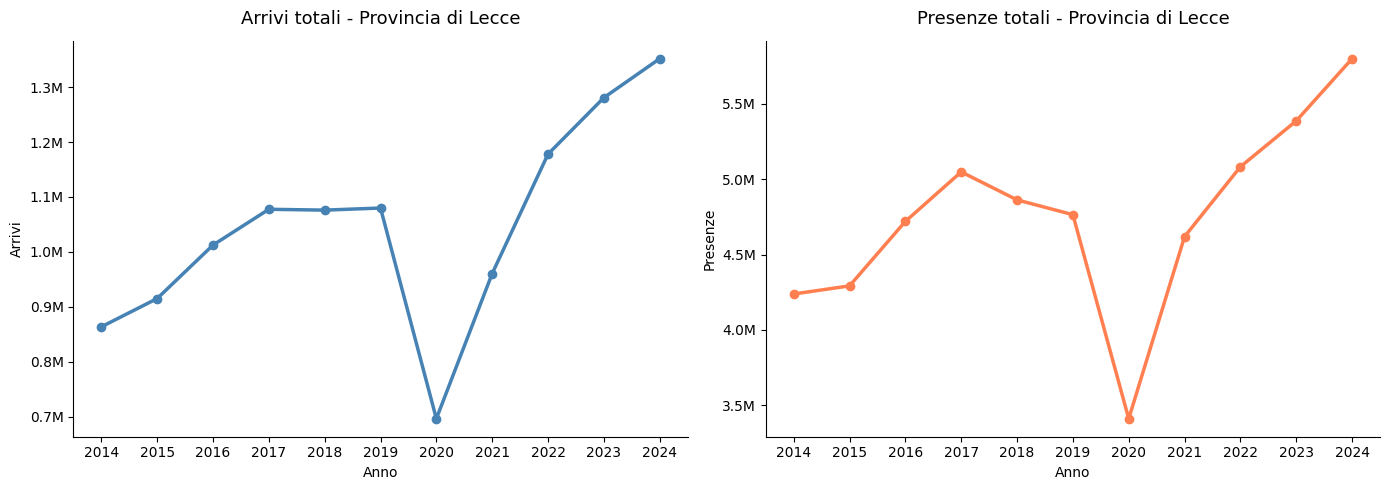

Grafico salvato


In [ ]:
#Grafico1: Trend arrivi e presense 2014-2024
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Arrivi
axes[0].plot(df_provincia['anno'], df_provincia['arrivi_totali'],
             marker='o', linewidth=2.5, color='steelblue')
axes[0].set_title('Arrivi totali - Provincia di Lecce', fontsize=13, pad=12)
axes[0].set_xlabel('Anno')
axes[0].set_ylabel('Arrivi')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
axes[0].set_xticks(df_provincia['anno'])

# Presenze
axes[1].plot(df_provincia['anno'], df_provincia['presenze_totali'],
             marker='o', linewidth=2.5, color='coral')
axes[1].set_title('Presenze totali - Provincia di Lecce', fontsize=13, pad=12)
axes[1].set_xlabel('Anno')
axes[1].set_ylabel('Presenze')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
axes[1].set_xticks(df_provincia['anno'])

plt.tight_layout()
plt.savefig('trend_arrivi_presenze.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafico salvato")

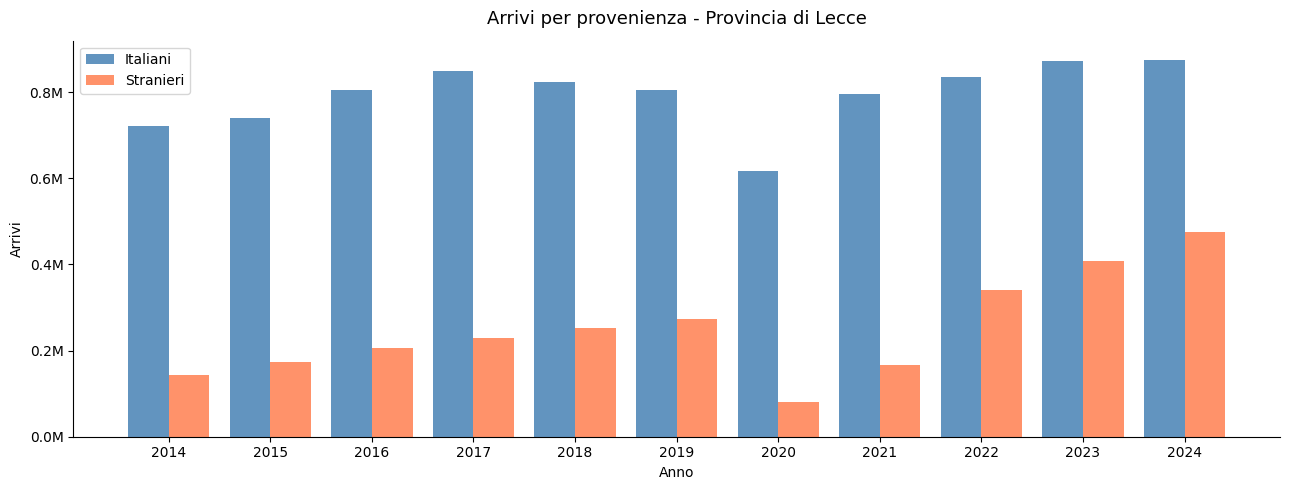

In [ ]:
#Grafico2: Italiani vs Stranieri
fig, ax = plt.subplots(figsize=(13, 5))

ax.bar(df_provincia['anno'] - 0.2, df_provincia['arrivi_italiani'],
       width=0.4, label='Italiani', color='steelblue', alpha=0.85)
ax.bar(df_provincia['anno'] + 0.2, df_provincia['arrivi_stranieri'],
       width=0.4, label='Stranieri', color='coral', alpha=0.85)

ax.set_title('Arrivi per provenienza - Provincia di Lecce', fontsize=13, pad=12)
ax.set_xlabel('Anno')
ax.set_ylabel('Arrivi')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.set_xticks(df_provincia['anno'])
ax.legend()

plt.tight_layout()
plt.savefig('italiani_vs_stranieri.png', dpi=150, bbox_inches='tight')
plt.show()

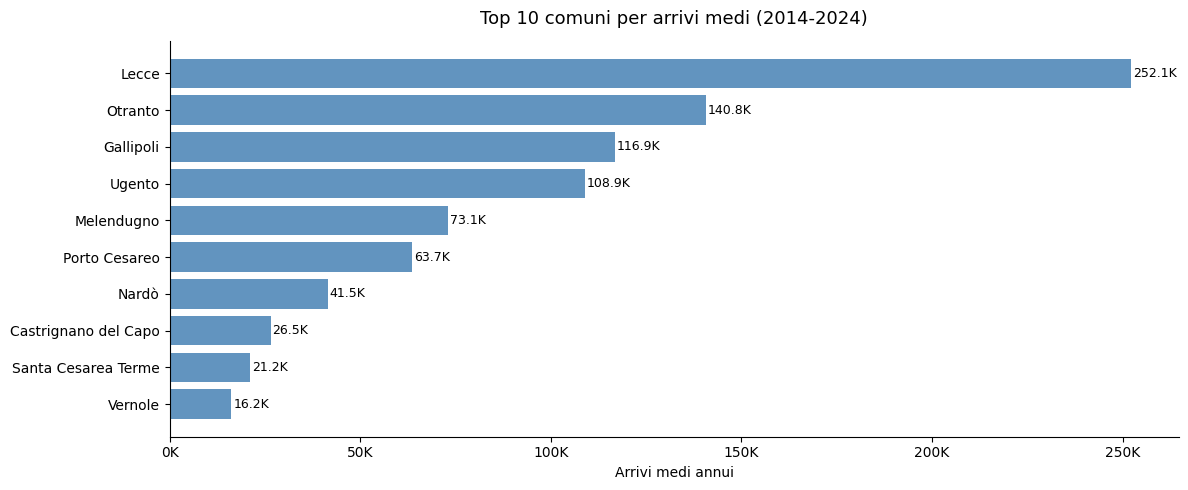

In [ ]:
#Grafico3: Top 10 comuni per arrivi (2014-2024)
# Escludi la riga "Altri comuni"
df_comuni = df[~df['comune'].str.startswith('Altri')].copy()

top10 = (df_comuni.groupby('comune')['arr_tot_tot']
         .mean()
         .sort_values(ascending=False)
         .head(10)
         .reset_index())

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(top10['comune'], top10['arr_tot_tot'], color='steelblue', alpha=0.85)
ax.invert_yaxis()
ax.set_title('Top 10 comuni per arrivi medi (2014-2024)', fontsize=13, pad=12)
ax.set_xlabel('Arrivi medi annui')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

# Etichette sui bar
for bar, val in zip(bars, top10['arr_tot_tot']):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'{val/1e3:.1f}K', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('top10_comuni.png', dpi=150, bbox_inches='tight')
plt.show()

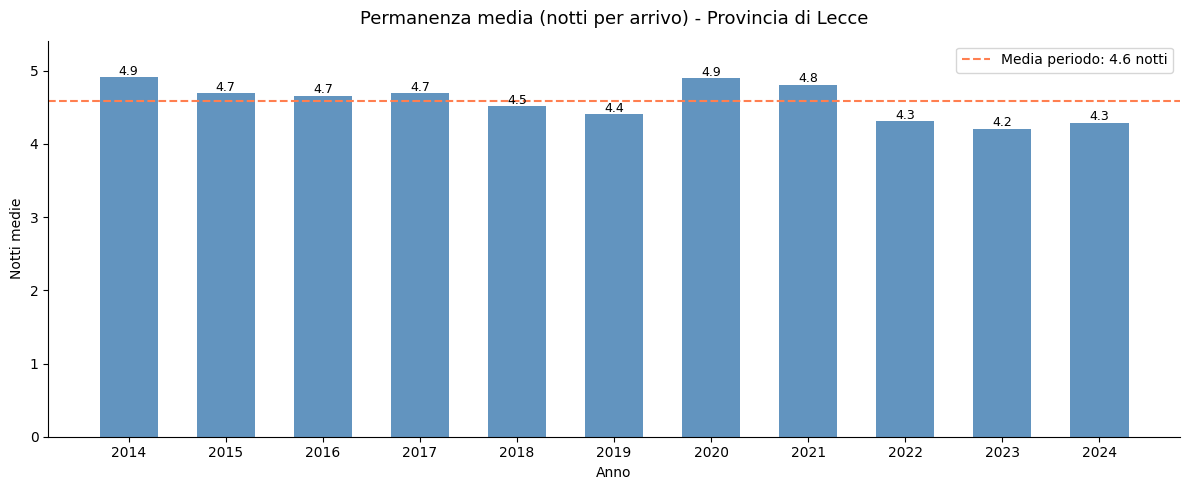

In [ ]:
#Permanenza Media
fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(df_provincia['anno'], df_provincia['permanenza_media'],
       color='steelblue', alpha=0.85, width=0.6)

# Linea media generale
media = df_provincia['permanenza_media'].mean()
ax.axhline(media, color='coral', linestyle='--', linewidth=1.5,
           label=f'Media periodo: {media:.1f} notti')

# Etichette sui bar
for _, row in df_provincia.iterrows():
    ax.text(row['anno'], row['permanenza_media'] + 0.03,
            f"{row['permanenza_media']:.1f}", ha='center', fontsize=9)

ax.set_title('Permanenza media (notti per arrivo) - Provincia di Lecce',
             fontsize=13, pad=12)
ax.set_xlabel('Anno')
ax.set_ylabel('Notti medie')
ax.set_ylim(0, df_provincia['permanenza_media'].max() + 0.5)
ax.set_xticks(df_provincia['anno'])
ax.legend()

plt.tight_layout()
plt.savefig('permanenza_media.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# NOTEBOOK 2 - ANALISI ESPLORATIVA
# ============================================================
# KPI analizzati:
# - Trend arrivi e presenze 2014-2024
# - Composizione italiani vs stranieri
# - Top 10 comuni per volume di arrivi
# - Permanenza media per anno
#
# Insight principali:
# - 2024 anno record per arrivi e presenze
# - Forte crescita componente straniera dal 2022
# - Lecce, Otranto e Gallipoli dominano il territorio
# - Permanenza media stabile intorno alle 4-5 notti
# ============================================================

print("Analisi esplorativa completata. Pronti per il Notebook 3 - Forecasting")

Analisi esplorativa completata. Pronti per il Notebook 3 - Forecasting
